# Histogram Equalization

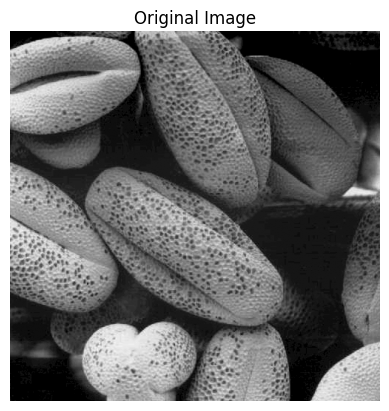

In [3]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2

#Load Image and View
image_gray = cv2.imread("shells.tif", cv2.IMREAD_GRAYSCALE)

# Display the original image
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

Equalization Function

In [6]:
def histogram_equalization(image):
  
    # Flatten the image array and calculate histogram
    hist, bins = np.histogram(image.flatten(), bins=256, range=[0,256])
    
    # Normalize 
    hist_norm = hist / hist.sum()
    
    # Compute the CDF
    cdf = hist_norm.cumsum()
    
    # Normalize the CDF to range [0, 255]
    cdf_normalized = np.round(cdf * 255).astype(np.uint8)
    
    # Use CDF  get the equalized pixel values
    image_equalized = cdf_normalized[image]
    
    return image_equalized

In [7]:
# Apply histogram equalization
image_equalized = histogram_equalization(image_gray)

plot histograms

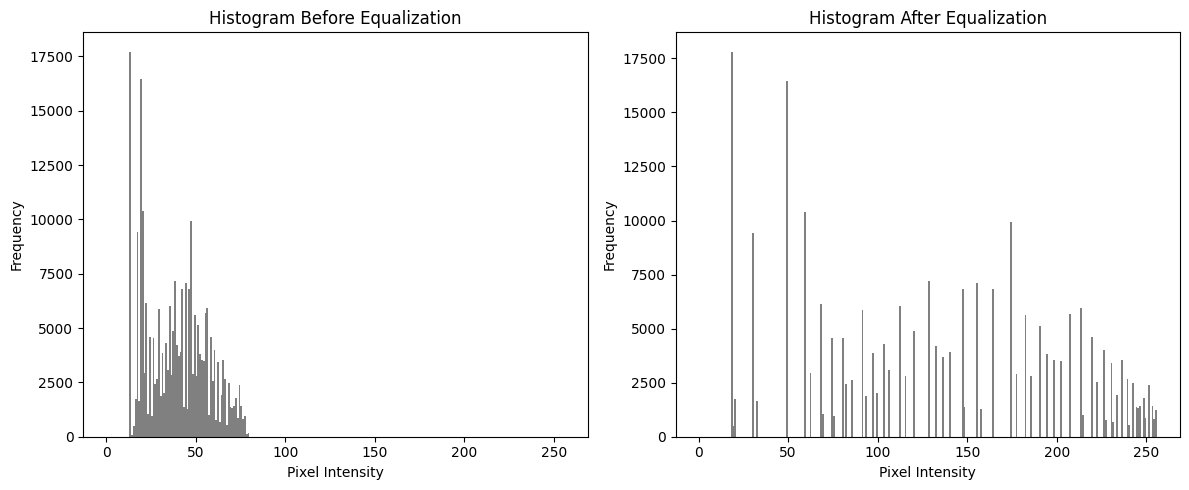

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title('Histogram Before Equalization')
plt.hist(image_gray.flatten(), bins=256, range=[0,256], color='gray')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.title('Histogram After Equalization')
plt.hist(image_equalized.flatten(), bins=256, range=[0,256], color='gray')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

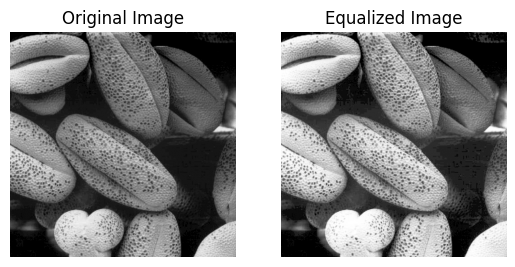

In [12]:

plt.subplot(1,2,1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(image_equalized, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')
plt.show()